## Градиентный бустинг



In [90]:
!pip install catboost

In [91]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [92]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


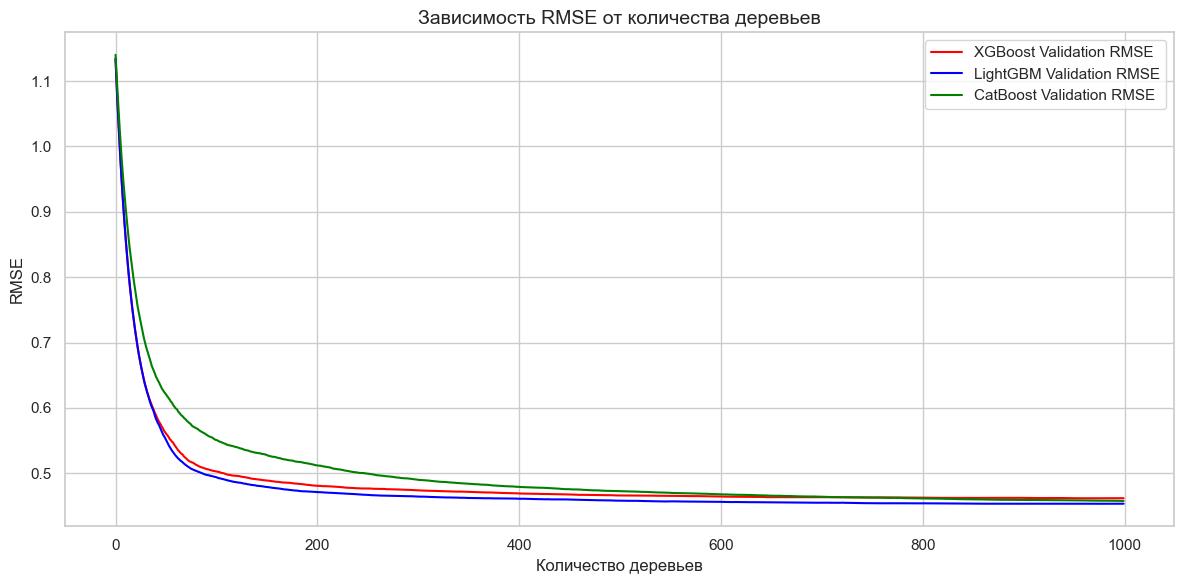

In [93]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [94]:
SELECTED_N_ESTIMATORS = 400

In [ ]:
class MyBoost:
    def __init__(self, n=400, learning_rate=0.05, subsample_size = 0.8, colsample_bytree = 0.8, depth=7, seed=42) -> None:
        self.n = n
        self.learning_rate = learning_rate
        self.depth = depth
        self.seed = seed
        self.trees = []
        self.tree_features = []
        self.importances = []
        self.subsample_size = subsample_size
        self.colsample_bytree = colsample_bytree
        
    def fit(self, X, y):
        X = self._encode_categoricals(X, fit=True)
        self.initial_leaf = y.mean()
        predictions = np.zeros(len(y)) +self.initial_leaf
        self.n_features_ = X.shape[1]

        for _ in range (self.n):
            X_sub, _, indices = self.subsample(X, y)
            X_sub_cols, chosen_cols = self.colsubsample(X_sub)
            self.tree_features.append(chosen_cols)

            antigrad = y - predictions
            antigrad_sub = antigrad[indices]
            tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion = 'friedman_mse')
            tree.fit(X_sub_cols, antigrad_sub)
            self.trees.append(tree)
            importance = tree.feature_importances_
            self.importances.append(importance)
            predictions += tree.predict(X.iloc[:, chosen_cols]) * self.learning_rate


    def predict(self, samples):
        samples = self._encode_categoricals(samples, fit=False)
        predictions = np.zeros(len(samples)) +self.initial_leaf

        for i in range (self.n):
            cols = self.tree_features[i]
            predictions += self.learning_rate * self.trees[i].predict(samples.iloc[:, cols])

        return predictions
    
    def subsample(self, X, y):
        size = int(self.subsample_size * X.shape[0])
        indices = np.random.choice(X.shape[0], size, replace=False)
        X_subsample = X.iloc[indices]
        y_subsample = y[indices]
        return X_subsample, y_subsample, indices
    def colsubsample(self,X):
        n_cols = int(self.colsample_bytree * len(range(X.shape[1])))
        chosen_cols = np.random.choice( X.shape[1], n_cols, replace=False)
        X_subsample_cols = X.iloc[:, chosen_cols]
        return X_subsample_cols, chosen_cols

    def feature_importances_(self):
        result = np.zeros(self.n_features_)

        for i in range(len(self.trees)):
            imp = self.importances[i]
            cols = self.tree_features[i]
            for j in range(len(cols)):
                result[cols[j]] += imp[j]

        result /= len(self.trees)

        total = result.sum()
        if total != 0:
            result /= total

        return result
    def _encode_categoricals(self, X, fit=False):
        X_encoded = X.copy()
        cat_cols = X_encoded.select_dtypes(include=['object', 'category']).columns

        if fit:
            self.cat_columns = list(cat_cols)
            self.cat_categories = {}
            for col in self.cat_columns:
                self.cat_categories[col] = list(X_encoded[col].unique())

        for col in self.cat_columns:
            for cat in self.cat_categories[col]:
                X_encoded[col + '_' + str(cat)] = (X_encoded[col] == cat).astype(int)
            X_encoded = X_encoded.drop(columns=[col])

        return X_encoded

    

In [96]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4619
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



In [97]:
results = []

for name in['XGBoost', 'LightGBM', 'CatBoost', 'MyBoost']:
    params = best_params_dict.get(name)

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        model = MyBoost()
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    if name =='MyBoost':
        importances = model.feature_importances_()
        feature_names = X.columns

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)


,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,0.865,0.2889,0.4455,0.8485
1,LightGBM,0.488,0.2862,0.4379,0.8537
2,CatBoost,1.507,0.2967,0.4493,0.8460
3,MyBoost,13.845,0.2899,0.4440,0.8496


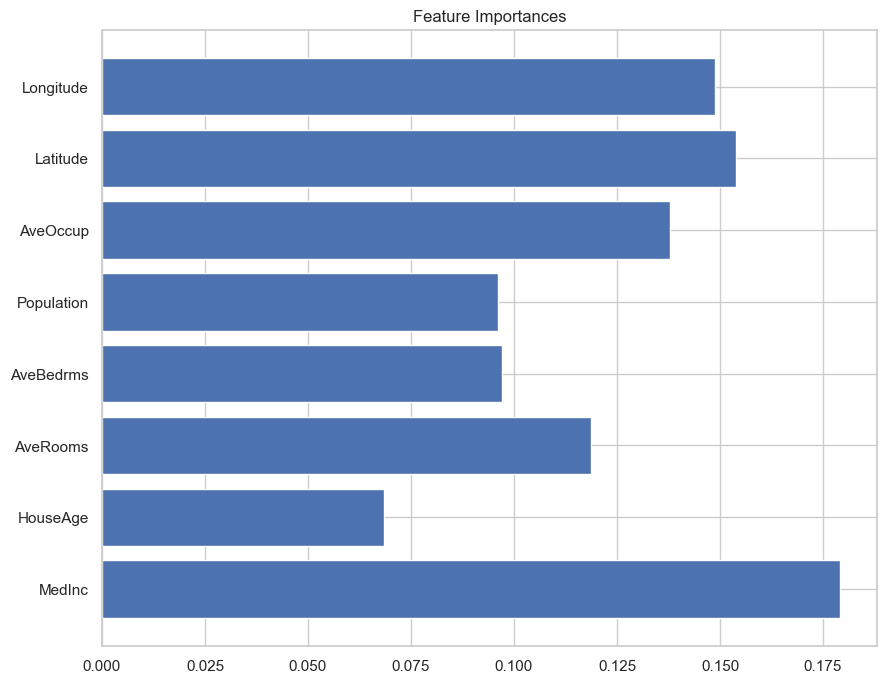

In [104]:
plt.figure(figsize=(10, 8))
plt.barh(feature_names, importances)
plt.title('Feature Importances')
plt.show()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


RMSE: 541.4384187344765
R2:   0.9815588567701714


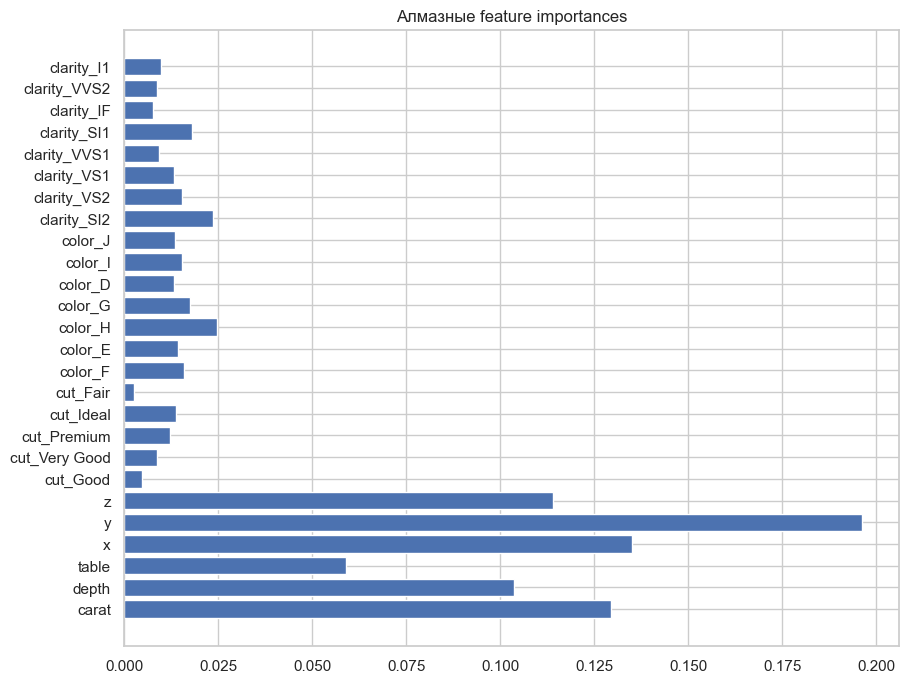

In [ ]:
diamonds = sns.load_dataset('diamonds')
display(diamonds.head())

X_diamonds = diamonds.drop(columns=['price'])
y_diamonds = diamonds['price'].values

X_dia_train, X_dia_test, y_dia_train, y_dia_test = train_test_split(X_diamonds, y_diamonds, test_size=0.2, random_state=42)


cat_model = MyBoost(n=200, learning_rate=0.1, depth=7, subsample_size=0.8, colsample_bytree=0.8)
cat_model.fit(X_dia_train, y_dia_train)
my_preds = cat_model.predict(X_dia_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_dia_test, my_preds))}")
print(f"R2:   {r2_score(y_dia_test, my_preds)}")


importances_diamonds = cat_model.feature_importances_()
encoded_features = cat_model._encode_categoricals(X_dia_train, fit=False).columns

plt.figure(figsize=(10, 8))
plt.barh(encoded_features, importances_diamonds)
plt.title('Алмазные feature importances')
plt.show()